In [ ]:
#Importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

#Loading the dataset
file_path = r"C:/Users/xavie/Downloads/HeartFailureData.csv"
data = pd.read_csv("C:/Users\/xavie/downloads/HeartFailureData.csv")

#Inspecting the dataset
data.head()


<>:8: SyntaxWarning: invalid escape sequence '\/'
<>:8: SyntaxWarning: invalid escape sequence '\/'
C:\Users\xavie\AppData\Local\Temp\ipykernel_38908\2522297649.py:8: SyntaxWarning: invalid escape sequence '\/'
  data = pd.read_csv("C:/Users\/xavie/downloads/HeartFailureData.csv")


,pat_mrn_id,age,female,weight_last_kg,NYHA_class,EF,ischemic_etiology,SBP,percent_lymphocytes,sodium,...,statin_use,ACE_inhibitor,beta_blocker,angiotensin_receptor_blocker,potassium_sparing_diuretic,ICD_use,biventricular_ICD,biventricular_pacemaker,LVAD,Alive
0,15,90.0,1,54.61,3,68,0,138,27.0,143,...,0,0,1,0,0,0,0,0,0,1
1,60,75.0,1,79.38,3,30,1,102,28.0,138,...,1,0,1,1,1,0,0,0,0,1
2,95,87.0,1,51.71,3,59,1,155,16.0,136,...,1,0,1,1,0,0,0,0,0,1
3,150,74.0,0,56.70,3,53,1,91,8.0,137,...,1,0,0,0,0,0,0,0,0,1
4,244,80.0,1,83.20,3,53,0,128,21.0,141,...,1,1,1,0,0,0,0,0,0,1


In [ ]:
#Dropping the 'pat_mrn_id' column as it is an identifier and not useful for prediction
data = data.drop(columns=["pat_mrn_id"])

X = data.drop(columns=["Alive"])
y = data["Alive"]

# Splitting into train/test sets (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Random Forest Classifier
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

#Printing the results
print("Accuracy:", round(accuracy, 3))
print("F1 Score:", round(f1, 3))

Accuracy: 0.896
F1 Score: 0.945


{
  "ml_method": "Random Forest Classifier",
  "training/testing regime": "80/20 split, stratified sampling for class balance",
  "performance metrics": {
    "accuracy": "0.896",
    "F1-score": "0.945"}
}

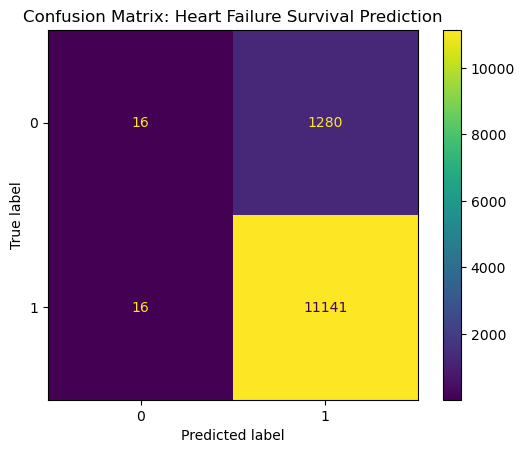

In [7]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix: Heart Failure Survival Prediction")
plt.show()